# TP — CRISP-DM et apprentissage supervisé  
## Classification et régression avec une seule base de données

**Version énoncé sans code**  
**Niveau : débutant / intermédiaire**  
**Durée : 3 heures**  
**Support : cours + figures + TP guidé**

---

## Objectif général

Ce TP permet de comprendre les bases du **Machine Learning supervisé** en travaillant avec une seule base de données.

Nous allons traiter deux problèmes :

1. **Régression** : prédire une valeur numérique.
2. **Classification** : prédire une catégorie.

La démarche suivra la logique **CRISP-DM** : comprendre le problème, comprendre les données, préparer les données, modéliser, évaluer et interpréter.

# Plan de la séance

| Partie | Durée | Contenu |
|---|---:|---|
| 1 | 20 min | Rappel IA, ML et apprentissage supervisé |
| 2 | 25 min | CRISP-DM et démarche projet |
| 3 | 30 min | Découverte et visualisation des données |
| 4 | 35 min | Problème 1 : régression |
| 5 | 45 min | Problème 2 : classification |
| 6 | 25 min | Évaluation et interprétation |
| 7 | 20 min | Synthèse et questions |

# 1. Rappel : IA, Machine Learning et Deep Learning

L’**Intelligence Artificielle** est le domaine général qui cherche à créer des systèmes capables de réaliser des tâches qui demandent habituellement de l’intelligence humaine.

Le **Machine Learning** est une sous-partie de l’IA.  
Au lieu d’écrire toutes les règles à la main, on donne des exemples au modèle pour qu’il apprenne à partir des données.

Le **Deep Learning** est une sous-partie du Machine Learning basée sur les réseaux de neurones profonds.

L’**IA générative** correspond aux modèles capables de produire du texte, des images, du code ou d’autres contenus.

![IA ML DL GenAI](attachment:01_ai_ml_dl_genai.png)

## À retenir

Le Machine Learning ne remplace pas la réflexion humaine.  
Il aide à apprendre des régularités à partir des données pour faire des prédictions ou prendre des décisions.

# 2. Apprentissage supervisé

Un problème est **supervisé** lorsque l’on connaît déjà la réponse attendue pour les exemples d’entraînement.

Le modèle reçoit :

- des variables explicatives : `X` ;
- une cible à prédire : `y`.

Il apprend une relation entre `X` et `y`.

![Classification vs régression](attachment:04_classification_vs_regression.png)

# 3. Classification ou régression ?

## Régression

La régression consiste à prédire une **valeur numérique**.

Exemples :

- prédire un prix ;
- prédire une température ;
- prédire un score médical ;
- prédire une consommation.

## Classification

La classification consiste à prédire une **classe**.

Exemples :

- spam / non spam ;
- malade / non malade ;
- risque faible / risque élevé ;
- client satisfait / non satisfait.

# 4. CRISP-DM : méthode de projet Machine Learning

CRISP-DM signifie **Cross Industry Standard Process for Data Mining**.

C’est une méthode simple pour organiser un projet Data / Machine Learning.

Les étapes sont :

1. Compréhension métier.
2. Compréhension des données.
3. Préparation des données.
4. Modélisation.
5. Évaluation.
6. Déploiement et suivi.

![CRISP-DM](attachment:02_crispdm_cycle.png)

## Application dans ce TP

Dans ce TP :

- le **besoin métier** est de prédire un indicateur médical ;
- les **données** proviennent du dataset Diabetes ;
- la **préparation** inclut train/test split et StandardScaler ;
- la **modélisation** inclut un modèle de régression et un modèle de classification ;
- l’**évaluation** utilise des métriques adaptées.

![Pipeline ML](attachment:03_pipeline_ml.png)

# 5. Base de données utilisée

Nous utilisons la base **Diabetes** de `scikit-learn`.

Cette base contient :

- 442 observations ;
- 10 variables numériques ;
- une cible numérique : un score de progression de la maladie.

Avec cette même base :

- nous allons prédire le score directement : **régression** ;
- puis transformer le score en deux classes : **classification**.

## Travail demandé

Importer les bibliothèques nécessaires :

- `numpy`
- `pandas`
- `matplotlib`
- les outils nécessaires de `scikit-learn`

### Question

Pourquoi utilise-t-on `scikit-learn` dans ce TP ?

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import load_diabetes
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

%matplotlib inline

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


**Réponses :**
On utilise `scikit-learn` car cette bibliothèque fournit des outils simples pour charger des datasets, préparer les données, créer des modèles de Machine Learning, entraîner ces modèles et les évaluer avec des métriques adaptées.

# 6. Chargement des données

Dans cette étape, on charge le dataset et on le transforme en tableau pour mieux le lire.

## Travail demandé

1. Charger le dataset Diabetes.
2. Stocker les variables explicatives dans `X`.
3. Stocker la cible numérique dans `y`.
4. Transformer les données en `DataFrame`.
5. Afficher les cinq premières lignes.

## Questions

1. Combien y a-t-il d’observations ?
2. Combien y a-t-il de variables explicatives ?
3. La cible est-elle numérique ou catégorielle ?

In [20]:
diabetes = load_diabetes()

x = diabetes.data

y = diabetes.target

df = pd.DataFrame(x, columns=diabetes.feature_names)
df["target"] = y

df.head()




,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [21]:
print("Nombre d'observations :", x.shape[0])
print("Nombre de variables :", x.shape[1])
print("Type de la cible :", df["target"].dtype)


Nombre d'observations : 442
Nombre de variables : 10
Type de la cible : float64


**Réponses :**
1. Il y a **442 observations**.  
2. Il y a **10 variables explicatives**.  
3. La cible est **numérique**, donc elle peut être utilisée pour un problème de régression.

# 7. Compréhension des données

Avant de modéliser, il faut observer les données.

Cette étape permet de répondre à des questions simples :

- Quelles sont les variables ?
- Les valeurs sont-elles numériques ?
- Quelle est la distribution de la cible ?
- Certaines variables semblent-elles liées à la cible ?

## Travail demandé

1. Afficher les statistiques descriptives.
2. Tracer un histogramme de la cible.
3. Tracer un nuage de points entre une variable explicative et la cible.

## Questions

1. La cible semble-t-elle très dispersée ?
2. La variable observée semble-t-elle liée à la cible ?
3. Pourquoi visualiser les données avant de construire un modèle ?

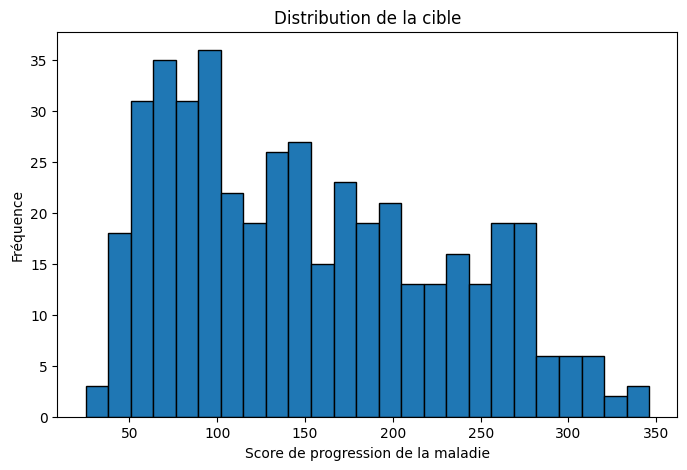

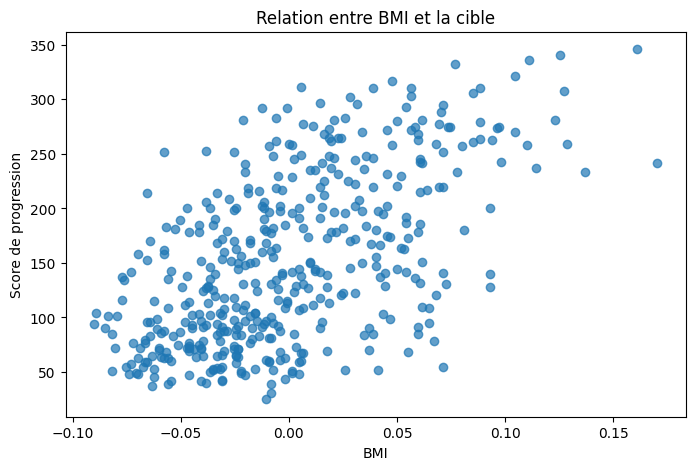

In [25]:
df.describe()

plt.figure(figsize=(8, 5))
plt.hist(df["target"], bins=25, edgecolor="black")
plt.title("Distribution de la cible")
plt.xlabel("Score de progression de la maladie")
plt.ylabel("Fréquence")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["bmi"], df["target"], alpha=0.7)
plt.title("Relation entre BMI et la cible")
plt.xlabel("BMI")
plt.ylabel("Score de progression")
plt.show()

**Réponses :**
1. Oui, la cible est assez dispersée : les valeurs de progression varient beaucoup selon les patients.  
2. La variable `bmi` semble avoir une relation positive avec la cible : quand `bmi` augmente, le score a tendance à augmenter.  
3. Visualiser les données permet de mieux comprendre leur distribution, repérer des tendances, détecter des valeurs anormales et choisir une bonne stratégie de modélisation.

# 8. Préparation des données : train/test split

Le modèle ne doit pas être évalué sur les mêmes données que celles utilisées pour l’apprentissage.

On sépare donc les données en :

- **train set** : pour apprendre ;
- **test set** : pour évaluer.

![Train test split](attachment:05_train_test_split.png)

## Travail demandé

1. Séparer les données en train et test.
2. Utiliser 80 % des données pour l’entraînement.
3. Utiliser 20 % pour le test.
4. Afficher la taille des deux ensembles.

## Question

Pourquoi le test set doit-il rester non vu pendant l’entraînement ?

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print("Taille de X_train :", X_train.shape)
print("Taille de X_test :", X_test.shape)
print("Taille de y_train :", y_train.shape)
print("Taille de y_test :", y_test.shape)

Taille de X_train : (353, 10)
Taille de X_test : (89, 10)
Taille de y_train : (353,)
Taille de y_test : (89,)


**Réponse :**  
Le test set doit rester non vu pendant l'entraînement pour mesurer la capacité du modèle à généraliser sur de nouvelles données. Sinon, l'évaluation serait trop optimiste.

# 9. StandardScaler

Le `StandardScaler` est une étape de prétraitement.

Il transforme les variables numériques pour obtenir :

- une moyenne proche de 0 ;
- un écart-type proche de 1.

Cela permet de mettre les variables sur une échelle comparable.

![StandardScaler](attachment:06_standard_scaler.png)

## À retenir

On ajuste le scaler sur le **train set** uniquement.  
Ensuite, on applique la même transformation au **test set**.

Cela évite une fuite d’information du test vers l’entraînement.

# Partie A — Problème de régression

## Objectif

Prédire le score numérique de progression.

Comme la cible est une valeur numérique, il s’agit d’un problème de **régression**.

Nous allons utiliser un modèle simple : **Linear Regression**.

## Travail demandé

1. Créer un pipeline avec :
   - `StandardScaler`
   - `LinearRegression`
2. Entraîner le modèle sur le train set.
3. Prédire les valeurs sur le test set.

## Question

Pourquoi ce problème est-il une régression ?

In [28]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [33]:
pipeline.fit(X_train,y_train)
print("Pipeline entraîné avec succès.")

Pipeline entraîné avec succès.


In [35]:
y_pred = pipeline.predict(X_test)

pd.DataFrame({
    "Valeur réelle": y_test[:10],
    "Valeur prédite": y_pred[:10]
})

,Valeur réelle,Valeur prédite
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659
5,84.0,92.172347
6,242.0,258.232389
7,272.0,181.337321
8,94.0,90.224113
9,96.0,108.633759


**Réponse :**  
Ce problème est une régression car la cible à prédire est une valeur numérique : le score de progression de la maladie.

# 10. Évaluation de la régression

Pour évaluer une régression, on peut utiliser :

- **MAE** : erreur absolue moyenne ;
- **RMSE** : racine de l’erreur quadratique moyenne ;
- **R²** : part de variance expliquée par le modèle.

## Travail demandé

1. Calculer MAE.
2. Calculer RMSE.
3. Calculer R².
4. Tracer un graphique valeurs réelles vs valeurs prédites.

## Questions

1. À quoi correspond une erreur élevée ?
2. Que signifie un R² proche de 1 ?
3. Les prédictions semblent-elles proches des vraies valeurs ?

In [37]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

MAE  : 42.79
RMSE : 53.85
R²   : 0.45


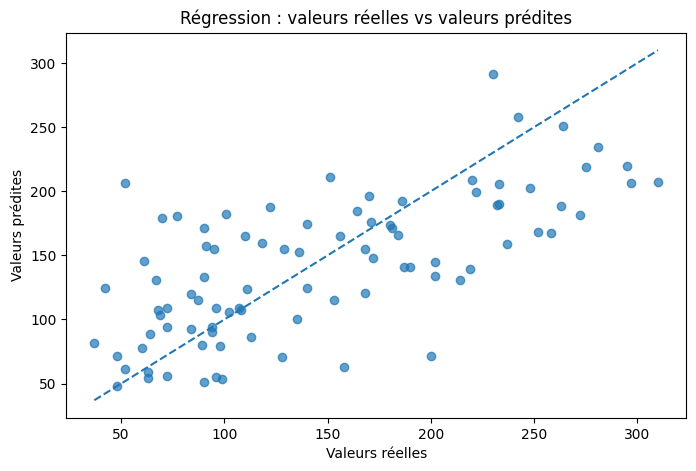

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Régression : valeurs réelles vs valeurs prédites")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.show()

**Réponses :**

1. Une erreur élevée signifie que les prédictions du modèle sont loin des vraies valeurs.  
2. Un R² proche de 1 signifie que le modèle explique une grande partie de la variance de la cible.  
3. Les prédictions suivent partiellement les vraies valeurs, mais il existe encore des écarts : le modèle linéaire reste simple.

# Partie B — Problème de classification

## Objectif

Nous allons transformer la cible numérique en deux classes :

- `0` : progression faible ;
- `1` : progression élevée.

Pour cela, on utilise la médiane comme seuil.

## Travail demandé

1. Calculer la médiane de la cible.
2. Créer une nouvelle cible :
   - 0 si la progression est inférieure à la médiane ;
   - 1 si la progression est supérieure ou égale à la médiane.
3. Afficher la répartition des classes.

## Questions

1. Pourquoi transforme-t-on la cible numérique ?
2. Les classes sont-elles équilibrées ?
3. Pourquoi l’équilibre des classes est-il important ?

Médiane de la cible : 140.5
0    221
1    221
Name: count, dtype: int64


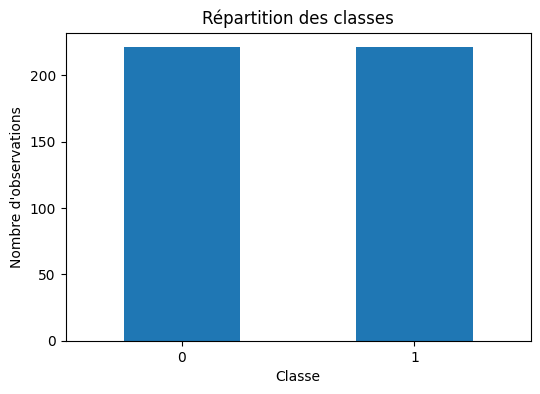

In [41]:
median_target = np.median(y)
print("Médiane de la cible :", median_target)

y_class = (y >= median_target).astype(int)



class_counts = pd.Series(y_class).value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Répartition des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()

**Réponses :**

1. On transforme la cible numérique pour créer un problème de classification : progression faible ou élevée.  
2. Les classes sont presque équilibrées, car la médiane sépare les données en deux groupes de taille proche.  
3. L'équilibre des classes est important pour éviter qu'un modèle favorise seulement la classe majoritaire.

# 11. Nouvelle séparation train/test pour la classification

Comme la cible a changé, on refait une séparation train/test avec la nouvelle cible.

## Travail demandé

Séparer les données en train/test pour la classification.

Utiliser `stratify` pour conserver la proportion des classes.

## Question

Pourquoi utilise-t-on `stratify` dans un problème de classification ?

In [43]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    x,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Répartition train :")
print(pd.Series(y_train_clf).value_counts(normalize=True).sort_index())

print("\nRépartition test :")
print(pd.Series(y_test_clf).value_counts(normalize=True).sort_index())

Répartition train :
0    0.498584
1    0.501416
Name: proportion, dtype: float64

Répartition test :
0    0.505618
1    0.494382
Name: proportion, dtype: float64


**Réponse :**  
On utilise `stratify` pour garder la même proportion de classes dans le train set et dans le test set.

# 12. Modèle de classification

Nous allons utiliser un modèle simple : **Logistic Regression**.

Malgré son nom, la régression logistique est utilisée pour la **classification**.

## Travail demandé

1. Créer un pipeline avec :
   - `StandardScaler`
   - `LogisticRegression`
2. Entraîner le modèle.
3. Prédire les classes sur le test set.

## Question

Pourquoi ce problème est-il une classification ?

In [44]:
classification_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])


classification_model.fit(X_train_clf, y_train_clf)


y_pred_clf = classification_model.predict(X_test_clf)

# Affichage
pd.DataFrame({
    "Classe réelle": y_test_clf[:10],
    "Classe prédite": y_pred_clf[:10]
})

,Classe réelle,Classe prédite
0,1,1
1,1,0
2,0,0
3,1,1
4,1,1
5,0,1
6,0,0
7,1,1
8,1,1
9,0,0


**Réponse :**  
Ce problème est une classification car on ne prédit plus une valeur numérique exacte, mais une classe : progression faible `0` ou progression élevée `1`.

# 13. Évaluation de la classification

Pour la classification, les métriques principales sont :

- accuracy ;
- precision ;
- recall ;
- F1-score ;
- matrice de confusion.

![Matrice de confusion](attachment:07_confusion_matrix.png)

![Métriques de classification](attachment:08_metrics_recap.png)

## Travail demandé

1. Calculer accuracy.
2. Calculer precision.
3. Calculer recall.
4. Calculer F1-score.
5. Afficher la matrice de confusion.
6. Interpréter les erreurs.

## Questions

1. Quelle métrique mesure la proportion de bonnes prédictions ?
2. Quelle métrique est importante si l’on veut retrouver un maximum de vrais positifs ?
3. Que montre la matrice de confusion ?

In [45]:
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print("Accuracy  :", round(accuracy, 2))
print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))
print("F1-score  :", round(f1, 2))

Accuracy  : 0.74
Precision : 0.71
Recall    : 0.8
F1-score  : 0.75


In [46]:
print(classification_report(
    y_test_clf,
    y_pred_clf,
    target_names=["Progression faible", "Progression élevée"]
))

                    precision    recall  f1-score   support

Progression faible       0.78      0.69      0.73        45
Progression élevée       0.71      0.80      0.75        44

          accuracy                           0.74        89
         macro avg       0.74      0.74      0.74        89
      weighted avg       0.74      0.74      0.74        89



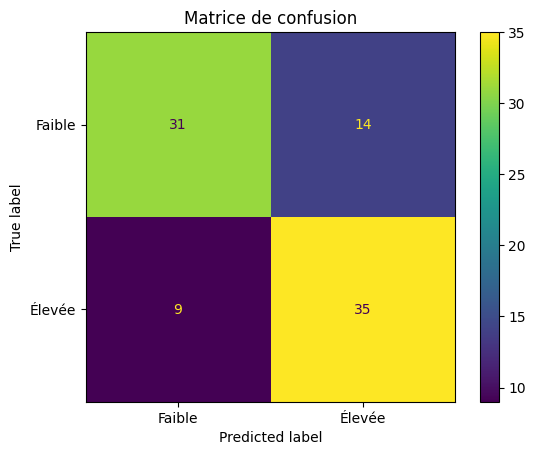

In [47]:
cm = confusion_matrix(y_test_clf, y_pred_clf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Faible", "Élevée"]
)

disp.plot()
plt.title("Matrice de confusion")
plt.show()

**Réponses :**

1. La métrique qui mesure la proportion de bonnes prédictions est l'**accuracy**.  
2. La métrique importante pour retrouver un maximum de vrais positifs est le **recall**.  
3. La matrice de confusion montre les bonnes prédictions et les erreurs du modèle : vrais positifs, vrais négatifs, faux positifs et faux négatifs.

# 14. Synthèse : deux problèmes, une seule base

Avec la même base de données, nous avons formulé deux problèmes :

| Partie | Cible | Type de problème |
|---|---|---|
| Régression | score numérique de progression | prédire une valeur |
| Classification | progression faible / élevée | prédire une classe |

Le choix entre classification et régression dépend donc de la **question métier**.

# 15. Questions finales

1. Qu’est-ce que CRISP-DM ?
2. Quelle est la différence entre classification et régression ?
3. Pourquoi séparer train et test ?
4. Quel est le rôle du StandardScaler ?
5. Pourquoi utilise-t-on des métriques différentes pour régression et classification ?
6. À quoi sert la matrice de confusion ?
7. Pourquoi la qualité des données est-elle importante ?
8. Quelles sont les limites de ce TP ?

## Réponses aux questions finales

1. **CRISP-DM** est une méthode qui organise un projet Data Science en plusieurs étapes : compréhension métier, compréhension des données, préparation, modélisation, évaluation et déploiement.  
2. La **régression** prédit une valeur numérique, alors que la **classification** prédit une catégorie.  
3. On sépare train et test pour évaluer le modèle sur des données qu'il n'a jamais vues.  
4. Le `StandardScaler` sert à mettre les variables sur une échelle comparable.  
5. Les métriques sont différentes car une erreur de valeur numérique ne s'évalue pas comme une erreur de classe.  
6. La matrice de confusion sert à analyser les bonnes et mauvaises prédictions d'un modèle de classification.  
7. La qualité des données est importante car un modèle apprend directement à partir des données. Des données mauvaises donnent souvent un mauvais modèle.  
8. Les limites de ce TP sont l'utilisation d'une petite base, de modèles simples et d'une transformation binaire simplifiée de la cible.

# 16. Travail à rendre

L’étudiant doit remettre :

1. le notebook complété ;
2. les graphiques générés ;
3. les résultats de la régression ;
4. les résultats de la classification ;
5. une conclusion courte de 10 à 15 lignes.

## Conclusion attendue

La conclusion doit expliquer :

- ce qui a été appris ;
- les différences entre les deux problèmes ;
- les résultats obtenus ;
- les limites du modèle ;
- une piste d’amélioration.